# Electricity Load Forecasting (Day Ahead)

The aim here is to predict the next 24 hours of electricity demand from past demand, time-related patterns and weather columns. I use the 2020–2024 hourly dataset and keep 2024 aside for the final test.

Columns used in the dataset: `Temperature`, `Humidity`, `Demand`.

**Sections**
1. Setup
2. Data checks
3. Explore the data
4. Build features
5. Split by time
6. Baseline forecasts
7. Train models
8. Test on 2024
9. Check errors and explain the model
10. Compare with the first version
11. Save the model
12. Summary

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import shap
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})

DATA_PATH = Path("electricityDemand.csv")
ARTIFACTS = Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)

## 2. Data checks

First I check the timestamps, missing values and unusual readings. For this project, the rows need to stay in hourly order because several features use demand from earlier hours.

In [2]:
raw = pd.read_csv()
print("Shape:", raw.shape)
display(raw.head(3))
display(raw.dtypes.to_frame("dtype").T)

Shape: (43848, 9)


,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403


,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
dtype,str,float64,float64,float64,float64,float64,float64,float64,float64


`Timestamp` has the date, and `hour` is in a separate column. I combine them into one hourly index. If I used the date column on its own, all 24 readings from the same day would have the same timestamp.

In [3]:
date = pd.to_datetime(raw["Timestamp"], format="%d-%b-%y")

# Every day must have exactly 24 rows, in chronological order
rows_per_day = date.value_counts()
assert (rows_per_day == 24).all() and date.is_monotonic_increasing

idx = pd.date_range(date.iloc[0], periods=len(raw), freq="h", name="timestamp")
assert (idx.normalize() == date.values).all()                       # dates agree
assert ((raw["hour"] == idx.hour) | raw["hour"].isna()).all()       # hour column agrees
assert ((raw["dayofweek"] == idx.dayofweek) | raw["dayofweek"].isna()).all()

print(f"{len(idx):,} rows  ->  {idx[0]}  to  {idx[-1]}  (complete hourly grid, no skipped hours)")

df = raw[["Temperature", "Humidity", "Demand"]].copy()
df.index = idx

43,848 rows  ->  2020-01-01 00:00:00  to  2024-12-31 23:00:00  (complete hourly grid, no skipped hours)


The dataset covers 1,827 days. That should give 43,848 hourly rows. The calendar columns already in the file have gaps, so I recreate them from the new datetime index instead.

Now I check how much data is missing.

In [4]:
missing = df.isna().sum().to_frame("missing"); missing["pct"] = (missing["missing"] / len(df) * 100).round(3)
display(missing)

all_empty = df.index[df.isna().all(axis=1)]
print(f"Rows with at least one NaN: {df.isna().any(axis=1).sum()}   |   fully empty rows: {len(all_empty)}")
print("Fully empty rows are consecutive hours:", list(all_empty.strftime('%Y-%m-%d %H:%M')))

# Longest run of consecutive missing Demand values
gap = df["Demand"].isna()
runs = gap.groupby((gap != gap.shift()).cumsum()).sum()
print("Longest gap in Demand (hours):", int(runs.max()))

,missing,pct
Temperature,7,0.016
Humidity,10,0.023
Demand,7,0.016


Rows with at least one NaN: 14   |   fully empty rows: 4
Fully empty rows are consecutive hours: ['2021-02-20 20:00', '2021-02-20 21:00', '2021-02-20 22:00', '2021-02-20 23:00']
Longest gap in Demand (hours): 4


### Missing values

There are very few missing values (about 0.07%), and the longest gap is four hours. I fill these short gaps using time interpolation.

I keep the rows that are completely empty. Dropping them would leave a gap in the hourly timeline and could cause problems when I create lag features. I set a six-hour limit on interpolation so that longer gaps are not filled automatically.

In [5]:
df = df.interpolate(method="time", limit=6, limit_direction="both")
assert df.isna().sum().sum() == 0
print("Missing values after cleaning:", int(df.isna().sum().sum()))

Missing values after cleaning: 0


### Plausibility checks

In [6]:
display(df.describe().T.round(2))

print(f"Temperature == 3 °C : {(df.Temperature == 3).mean():.1%} of rows")
print(f"Temperature == 50 °C: {(df.Temperature == 50).mean():.1%} of rows")
print("\nFive highest demand hours (do the spikes coincide with extreme heat?)")
display(df.nlargest(5, "Demand").round(1))

,count,mean,std,min,25%,50%,75%,max
Temperature,43848.0,25.07,12.82,3.00,15.21,25.00,34.74,50.00
Humidity,43848.0,59.90,18.34,20.00,46.24,59.98,73.80,95.00
Demand,43848.0,5000.64,1412.49,1611.95,4015.47,5012.91,6000.66,11910.71


Temperature == 3 °C : 4.5% of rows
Temperature == 50 °C: 1.6% of rows

Five highest demand hours (do the spikes coincide with extreme heat?)


,Temperature,Humidity,Demand
timestamp,,,
2024-07-10 19:00:00,38.5,60.5,11910.7
2022-06-07 11:00:00,47.2,52.1,10300.0
2024-06-24 20:00:00,34.2,40.7,10039.3
2024-07-19 18:00:00,42.7,73.2,8652.9
2021-04-01 18:00:00,19.4,33.3,8640.0


- `Temperature` has values capped at 3 °C and 50 °C. This could be a limit in the source data. I leave them in place, but the actual temperatures at the extremes may be higher or lower than recorded.
- Some demand values are quite high, mainly around 18:00–20:00 in warmer months. They look like real peak-demand periods, so I keep them rather than treating them as outliers.

## 3. Explore the data

I plot demand across the day and year, then check its relationship with temperature and earlier demand. This gives me a basis for choosing the features instead of adding every possible column.

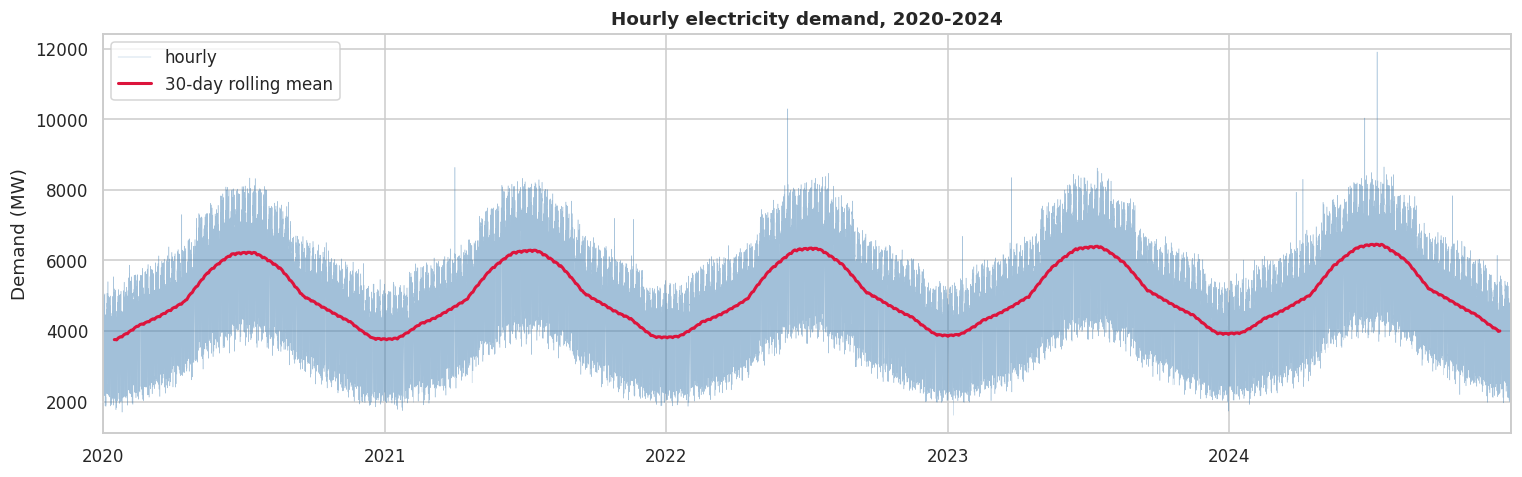

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.5))
df["Demand"].plot(ax=ax, lw=0.3, alpha=0.5, color="steelblue", label="hourly")
df["Demand"].rolling(24 * 30, center=True).mean().plot(ax=ax, lw=2, color="crimson", label="30-day rolling mean")
ax.set(title="Hourly electricity demand, 2020-2024", ylabel="Demand (MW)", xlabel="")
ax.legend(); plt.tight_layout(); plt.show()

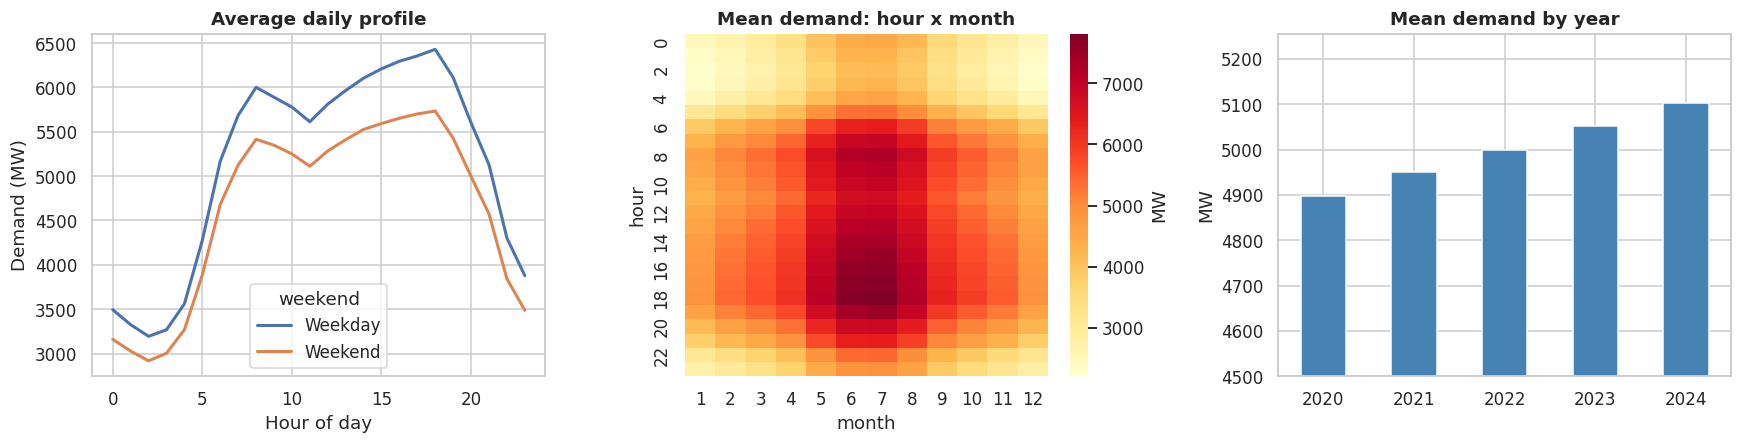

Weekend demand is 9.7% lower than weekday demand
Average yearly growth: 1.03%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) Daily profile, weekday vs weekend
prof = df.assign(hour=df.index.hour, weekend=np.where(df.index.dayofweek >= 5, "Weekend", "Weekday")) \
         .groupby(["hour", "weekend"])["Demand"].mean().unstack()
prof.plot(ax=axes[0], lw=2); axes[0].set(title="Average daily profile", ylabel="Demand (MW)", xlabel="Hour of day")

# (2) Hour x month heatmap
heat = df.assign(hour=df.index.hour, month=df.index.month).pivot_table(index="hour", columns="month", values="Demand")
sns.heatmap(heat, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "MW"}); axes[1].set(title="Mean demand: hour x month")

# (3) Yearly level
yr = df["Demand"].groupby(df.index.year).mean()
yr.plot.bar(ax=axes[2], color="steelblue", rot=0); axes[2].set(title="Mean demand by year", ylabel="MW", xlabel="")
axes[2].set_ylim(4500, yr.max() * 1.03)
plt.tight_layout(); plt.show()

print(f"Weekend demand is {1 - prof['Weekend'].mean() / prof['Weekday'].mean():.1%} lower than weekday demand")
print(f"Average yearly growth: {(yr.iloc[-1] / yr.iloc[0]) ** (1 / 4) - 1:.2%}")

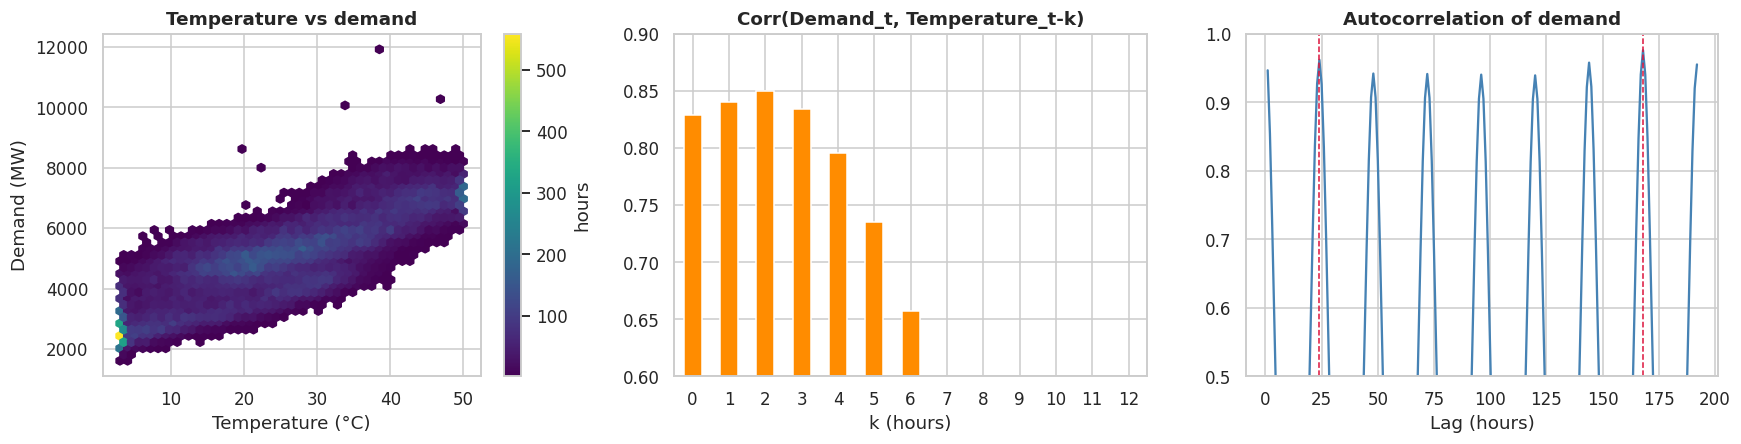

Corr(Demand, Temperature)  : 0.829
Corr(Demand, Humidity)     : -0.066
Autocorr at lag 24 / 168 h : 0.962 / 0.976


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) Temperature vs demand
hb = axes[0].hexbin(df["Temperature"], df["Demand"], gridsize=45, cmap="viridis", mincnt=1)
axes[0].set(title="Temperature vs demand", xlabel="Temperature (°C)", ylabel="Demand (MW)")
plt.colorbar(hb, ax=axes[0], label="hours")

# (2) Does demand react to *past* temperature? (thermal inertia)
lag_corr = pd.Series({l: df["Demand"].corr(df["Temperature"].shift(l)) for l in range(0, 13)})
lag_corr.plot.bar(ax=axes[1], color="darkorange", rot=0)
axes[1].set(title="Corr(Demand_t, Temperature_t-k)", xlabel="k (hours)", ylim=(0.6, 0.9))

# (3) Autocorrelation of demand
acf = pd.Series([df["Demand"].autocorr(l) for l in range(1, 24 * 8 + 1)], index=range(1, 24 * 8 + 1))
acf.plot(ax=axes[2], color="steelblue")
for l in (24, 168): axes[2].axvline(l, ls="--", color="crimson", lw=1)
axes[2].set(title="Autocorrelation of demand", xlabel="Lag (hours)", ylim=(0.5, 1))
plt.tight_layout(); plt.show()

print("Corr(Demand, Temperature)  :", round(df["Demand"].corr(df["Temperature"]), 3))
print("Corr(Demand, Humidity)     :", round(df["Demand"].corr(df["Humidity"]), 3))
print("Autocorr at lag 24 / 168 h :", round(acf[24], 3), "/", round(acf[168], 3))

### Patterns I noticed

| Pattern in the data | Feature choice |
|---|---|
| Demand is lowest around 03:00 and peaks around 18:00–19:00 | Hour-of-day features |
| Weekend demand is about 10% lower | Day of week and weekend flag |
| Demand increases with temperature (correlation is about 0.83) | Temperature and seasonal features |
| Temperature from a few hours earlier is also related to demand; the correlation is strongest near lag 2 | Lagged temperature |
| Humidity has little correlation with demand | Keep it for now and check whether the model uses it |
| Demand grows by roughly 1% per year | Do not use `year` directly as a tree-model feature |
| Demand is strongly related to the same hour last week (lag 168 correlation is about 0.976) | Demand lags at 24, 48, 168 and 336 hours, plus same-hour-of-week averages |

## 4. Forecast setup and features

The task is to predict all 24 hours of day D using information available by the end of day D−1.

For demand-based features, I shift demand by 24 hours before calculating rolling values. This means the features do not include the hour I am trying to predict. Calendar features come from the timestamp and are known in advance.

One limitation: the dataset has actual weather measurements, not archived weather forecasts. I use the observed temperature and humidity here, although a real day-ahead system would have to use forecast weather.

In [10]:
def build_features(d: pd.DataFrame) -> pd.DataFrame:
    """Leak-free feature set for a 24 h-ahead hourly forecast."""
    i, out = d.index, pd.DataFrame(index=d.index)

    # Calendar features; cyclical encoding keeps the wrap-around
    out["hour_sin"] = np.sin(2 * np.pi * i.hour / 24);        out["hour_cos"] = np.cos(2 * np.pi * i.hour / 24)
    out["month_sin"] = np.sin(2 * np.pi * i.month / 12);      out["month_cos"] = np.cos(2 * np.pi * i.month / 12)
    out["doy_sin"] = np.sin(2 * np.pi * i.dayofyear / 365.25); out["doy_cos"] = np.cos(2 * np.pi * i.dayofyear / 365.25)
    out["dow"] = i.dayofweek
    out["is_weekend"] = (i.dayofweek >= 5).astype(int)

    # Weather features, including the effect of recent temperature
    out["temperature"], out["humidity"] = d["Temperature"], d["Humidity"]
    for l in (1, 2, 3):
        out[f"temp_lag_{l}h"] = d["Temperature"].shift(l)
    out["temp_roll_6h"] = d["Temperature"].rolling(6).mean()
    out["temp_roll_24h"] = d["Temperature"].rolling(24).mean()

    # Demand history: all of these values are at least 24 hours old
    y = d["Demand"]
    for l in (24, 48, 72, 168, 336):
        out[f"demand_lag_{l}h"] = y.shift(l)
    y24 = y.shift(24)
    out["demand_roll_mean_24h"] = y24.rolling(24).mean()
    out["demand_roll_std_24h"] = y24.rolling(24).std()
    out["demand_roll_mean_168h"] = y24.rolling(168).mean()
    out["same_hour_mean_4w"] = pd.concat([y.shift(168 * k) for k in range(1, 5)], axis=1).mean(axis=1, skipna=False)
    return out

X_all = build_features(df)
y_all = df["Demand"]

# The longest lag is four weeks, so the first 672 rows have no complete feature set
valid = X_all.notna().all(axis=1)
print(f"Dropped {(~valid).sum()} warm-up rows ({(~valid).mean():.1%}); {valid.sum():,} rows remain, {X_all.shape[1]} features")
X_all, y_all = X_all[valid], y_all[valid]

# Check that no feature uses the target hour or anything after it
chk = X_all.copy(); chk["y"] = y_all
lagless = [c for c in chk.columns if c.startswith("demand_") or c == "same_hour_mean_4w"]
assert all(chk[c].corr(chk["y"]) < 0.999 for c in lagless)
print("Feature list:", list(X_all.columns))

Dropped 672 warm-up rows (1.5%); 43,176 rows remain, 24 features
Feature list: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow', 'is_weekend', 'temperature', 'humidity', 'temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 'temp_roll_6h', 'temp_roll_24h', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h', 'demand_lag_168h', 'demand_lag_336h', 'demand_roll_mean_24h', 'demand_roll_std_24h', 'demand_roll_mean_168h', 'same_hour_mean_4w']


## 5. Train, validation and test split

I keep the split chronological. Shuffling the rows would let information from later dates leak into training.

| Set | Dates | Purpose |
|---|---|---|
| Train | 2020-01-29 to 2022-12-31 | Fit models and run walk-forward CV |
| Validation | 2023 | Compare models and choose boosting rounds |
| Test | 2024 | Final check, after model choices are made |

In [11]:
train_mask = X_all.index < "2023-01-01"
val_mask = (X_all.index >= "2023-01-01") & (X_all.index < "2024-01-01")
test_mask = X_all.index >= "2024-01-01"

X_tr, y_tr = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_te, y_te = X_all[test_mask], y_all[test_mask]
X_trval, y_trval = X_all[train_mask | val_mask], y_all[train_mask | val_mask]

for name, a in [("Train", X_tr), ("Validation", X_val), ("Test", X_te)]:
    print(f"{name:<11}{a.index.min().date()} -> {a.index.max().date()}   {len(a):>6,} rows")

def evaluate(y_true, y_pred):
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "MAPE (%)": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
            "R2": float(r2_score(y_true, y_pred))}

Train      2020-01-29 -> 2022-12-31   25,632 rows
Validation 2023-01-01 -> 2023-12-31    8,760 rows
Test       2024-01-01 -> 2024-12-31    8,784 rows


## 6. Baseline forecasts

I compare the models with three simple forecasts first:

- **Naive-24:** use the demand from 24 hours ago.
- **Naive-168:** use the demand from 168 hours ago (same hour last week).
- **4-week mean:** average demand for the same hour over the previous four weeks.

These are useful reference points because electricity demand has clear daily and weekly patterns.

In [12]:
def baseline_preds(X):
    return {"Naive-24 (yesterday)": X["demand_lag_24h"],
            "Naive-168 (last week)": X["demand_lag_168h"],
            "Same-hour 4-week mean": X["same_hour_mean_4w"]}

val_results = {n: evaluate(y_val, p) for n, p in baseline_preds(X_val).items()}
pd.DataFrame(val_results).T.round(2)

,RMSE,MAE,MAPE (%),R2
Naive-24 (yesterday),388.35,296.41,6.20,0.92
Naive-168 (last week),308.19,238.07,5.06,0.95
Same-hour 4-week mean,355.79,283.50,5.88,0.94


## 7. Models

I try three models:

1. **Ridge regression** as a linear baseline.
2. **XGBoost**, which I used in the first version.
3. **LightGBM**, with randomized hyperparameter search and expanding-window cross-validation.

I use time-based validation rather than shuffled k-fold CV. In a forecasting task, training on dates later than the validation dates would not reflect real use.

### 7.1 Ridge

In [13]:
ridge_cols = [c for c in X_all.columns if c != "dow"]       # ordinal day-of-week is meaningless for a linear model; is_weekend covers it
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_tr[ridge_cols], y_tr)
val_results["Ridge"] = evaluate(y_val, ridge.predict(X_val[ridge_cols]))
pd.DataFrame(val_results).T.round(2).tail(1)

,RMSE,MAE,MAPE (%),R2
Ridge,162.49,125.33,2.68,0.99


### 7.2 XGBoost (early stopping on the validation year)

In [14]:
xgb_params = dict(learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                  min_child_weight=5, reg_lambda=1.0, objective="reg:squarederror",
                  random_state=SEED, n_jobs=-1)
xgb_model = xgb.XGBRegressor(n_estimators=3000, early_stopping_rounds=100, **xgb_params)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_best_iter = xgb_model.best_iteration + 1
val_results["XGBoost"] = evaluate(y_val, xgb_model.predict(X_val))
print("XGBoost best iteration:", xgb_best_iter)
pd.DataFrame(val_results).T.round(2).tail(1)

XGBoost best iteration: 1820


,RMSE,MAE,MAPE (%),R2
XGBoost,129.24,99.33,2.13,0.99


### 7.3 LightGBM: walk-forward CV

I use five expanding-window folds. Each validation fold is about 2.4 months long. The search uses only the training period; neither 2023 nor 2024 is included.

In [15]:
tscv = TimeSeriesSplit(n_splits=5, test_size=24 * 73)
rng = np.random.default_rng(SEED)
N_TRIALS = 20

def sample_params():
    return dict(num_leaves=int(rng.integers(15, 128)),
                min_child_samples=int(rng.integers(10, 101)),
                subsample=float(rng.uniform(0.6, 1.0)),
                colsample_bytree=float(rng.uniform(0.5, 1.0)),
                reg_lambda=float(10 ** rng.uniform(-3, 1)),
                reg_alpha=float(10 ** rng.uniform(-3, 0)))

fixed = dict(n_estimators=400, learning_rate=0.05, subsample_freq=1, random_state=SEED, n_jobs=-1, verbose=-1)
trials = []
for t in range(N_TRIALS):
    p = sample_params(); fold_rmse = []
    for tr_i, va_i in tscv.split(X_tr):
        m = lgb.LGBMRegressor(**fixed, **p).fit(X_tr.iloc[tr_i], y_tr.iloc[tr_i])
        fold_rmse.append(np.sqrt(mean_squared_error(y_tr.iloc[va_i], m.predict(X_tr.iloc[va_i]))))
    trials.append({**p, "cv_rmse": np.mean(fold_rmse), "cv_std": np.std(fold_rmse)})

trials = pd.DataFrame(trials).sort_values("cv_rmse").reset_index(drop=True)
display(trials.head(5).round(4))
best_params = trials.loc[0, ["num_leaves", "min_child_samples", "subsample", "colsample_bytree", "reg_lambda", "reg_alpha"]].to_dict()
best_params["num_leaves"] = int(best_params["num_leaves"]); best_params["min_child_samples"] = int(best_params["min_child_samples"])
print("Best params:", {k: round(v, 4) if isinstance(v, float) else v for k, v in best_params.items()})

,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda,reg_alpha,cv_rmse,cv_std
0,64,70,0.7884,0.7826,1.1481,0.0802,138.6617,11.5397
1,33,78,0.7418,0.9853,3.7367,0.2163,138.7364,12.0043
2,64,83,0.7550,0.6442,0.5370,0.0026,138.7810,12.2157
3,46,81,0.7836,0.7844,0.0036,0.0022,138.8486,12.4617
4,92,67,0.7447,0.5438,0.0030,0.7686,139.4748,11.8416


Best params: {'num_leaves': 64, 'min_child_samples': 70, 'subsample': 0.7884, 'colsample_bytree': 0.7826, 'reg_lambda': 1.1481, 'reg_alpha': 0.0802}


In [16]:
lgb_model = lgb.LGBMRegressor(n_estimators=4000, learning_rate=0.05, subsample_freq=1, random_state=SEED, n_jobs=-1, verbose=-1, **best_params)
lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="rmse",
              callbacks=[lgb.early_stopping(100, verbose=False)])
lgb_best_iter = lgb_model.best_iteration_
val_results["LightGBM (tuned)"] = evaluate(y_val, lgb_model.predict(X_val))
print("LightGBM best iteration:", lgb_best_iter)

val_table = pd.DataFrame(val_results).T.sort_values("RMSE").round(2)
print("\nVALIDATION (2023): used for model selection")
display(val_table)

LightGBM best iteration: 1028

VALIDATION (2023): used for model selection


,RMSE,MAE,MAPE (%),R2
XGBoost,129.24,99.33,2.13,0.99
LightGBM (tuned),129.93,100.07,2.14,0.99
Ridge,162.49,125.33,2.68,0.99
Naive-168 (last week),308.19,238.07,5.06,0.95
Same-hour 4-week mean,355.79,283.50,5.88,0.94
Naive-24 (yesterday),388.35,296.41,6.20,0.92


I compare the validation scores and choose the model from those results. I leave 2024 untouched until the final evaluation.

## 8. Final test on 2024

I refit the models on the 2020–2023 data. For the boosting models, I keep the number of rounds chosen using validation. Then I calculate the final scores on 2024.

In [17]:
final_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_trval[ridge_cols], y_trval)
final_xgb = xgb.XGBRegressor(n_estimators=xgb_best_iter, **xgb_params).fit(X_trval, y_trval)
final_lgb = lgb.LGBMRegressor(n_estimators=lgb_best_iter, learning_rate=0.05, subsample_freq=1,
                              random_state=SEED, n_jobs=-1, verbose=-1, **best_params).fit(X_trval, y_trval)

test_preds = {**baseline_preds(X_te),
              "Ridge": pd.Series(final_ridge.predict(X_te[ridge_cols]), index=X_te.index),
              "XGBoost": pd.Series(final_xgb.predict(X_te), index=X_te.index),
              "LightGBM (tuned)": pd.Series(final_lgb.predict(X_te), index=X_te.index)}

test_table = pd.DataFrame({n: evaluate(y_te, p) for n, p in test_preds.items()}).T.sort_values("RMSE").round(2)
print("TEST (2024): final, untouched hold-out")
display(test_table)

base = test_table.loc["Naive-168 (last week)", "RMSE"]
print(f"\nLightGBM reduces RMSE by {1 - test_table.loc['LightGBM (tuned)', 'RMSE'] / base:.0%} versus the seasonal-naive baseline")

TEST (2024): final, untouched hold-out


,RMSE,MAE,MAPE (%),R2
XGBoost,149.34,101.55,2.13,0.99
LightGBM (tuned),149.92,101.78,2.13,0.99
Ridge,179.91,128.13,2.68,0.98
Naive-168 (last week),321.01,237.82,4.94,0.95
Same-hour 4-week mean,362.65,285.23,5.82,0.93
Naive-24 (yesterday),399.37,299.23,6.18,0.92



LightGBM reduces RMSE by 53% versus the seasonal-naive baseline


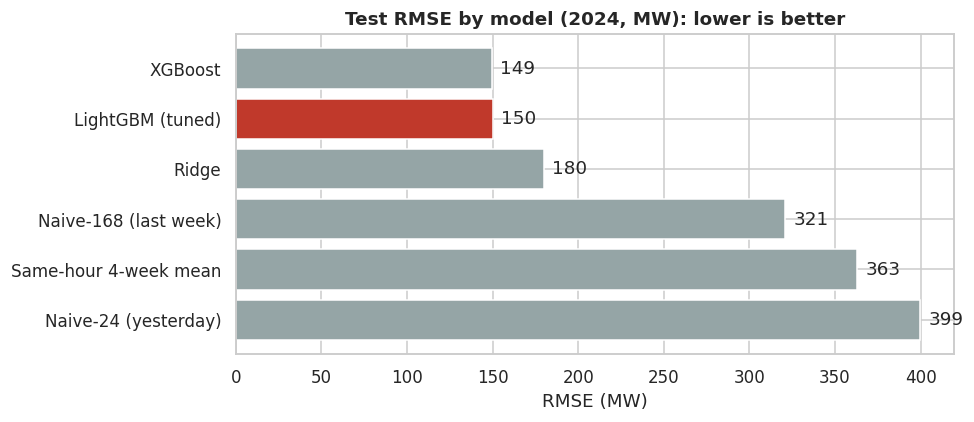

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
order = test_table.sort_values("RMSE", ascending=False)
colors = ["#c0392b" if n.startswith("LightGBM") else "#95a5a6" for n in order.index]
ax.barh(order.index, order["RMSE"], color=colors)
for y_, v in enumerate(order["RMSE"]): ax.text(v + 5, y_, f"{v:.0f}", va="center")
ax.set(title="Test RMSE by model (2024, MW): lower is better", xlabel="RMSE (MW)")
plt.tight_layout(); plt.show()

## 9. Errors and model interpretation

The overall score does not tell the whole story, so I also look at forecast plots, where the errors are largest, prediction intervals and feature importance.

### 9.1 Forecast vs actual

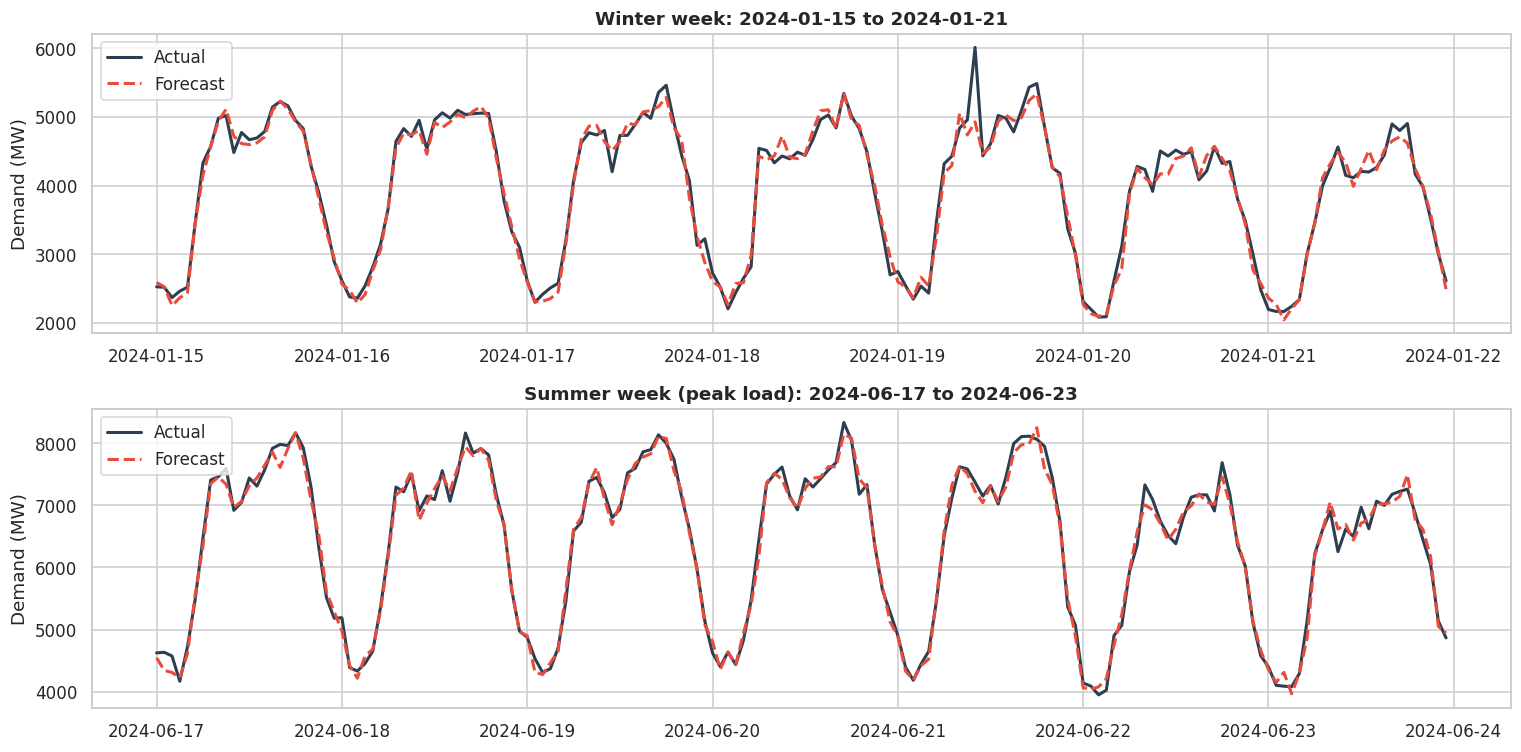

In [19]:
pred = test_preds["LightGBM (tuned)"]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, (a, b, title) in zip(axes, [("2024-01-15", "2024-01-21", "Winter week"), ("2024-06-17", "2024-06-23", "Summer week (peak load)")]):
    ax.plot(y_te[a:b].index, y_te[a:b], color="#2c3e50", lw=2, label="Actual")
    ax.plot(pred[a:b].index, pred[a:b], color="#e74c3c", lw=2, ls="--", label="Forecast")
    ax.set(title=f"{title}: {a} to {b}", ylabel="Demand (MW)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 9.2 Where are the errors?

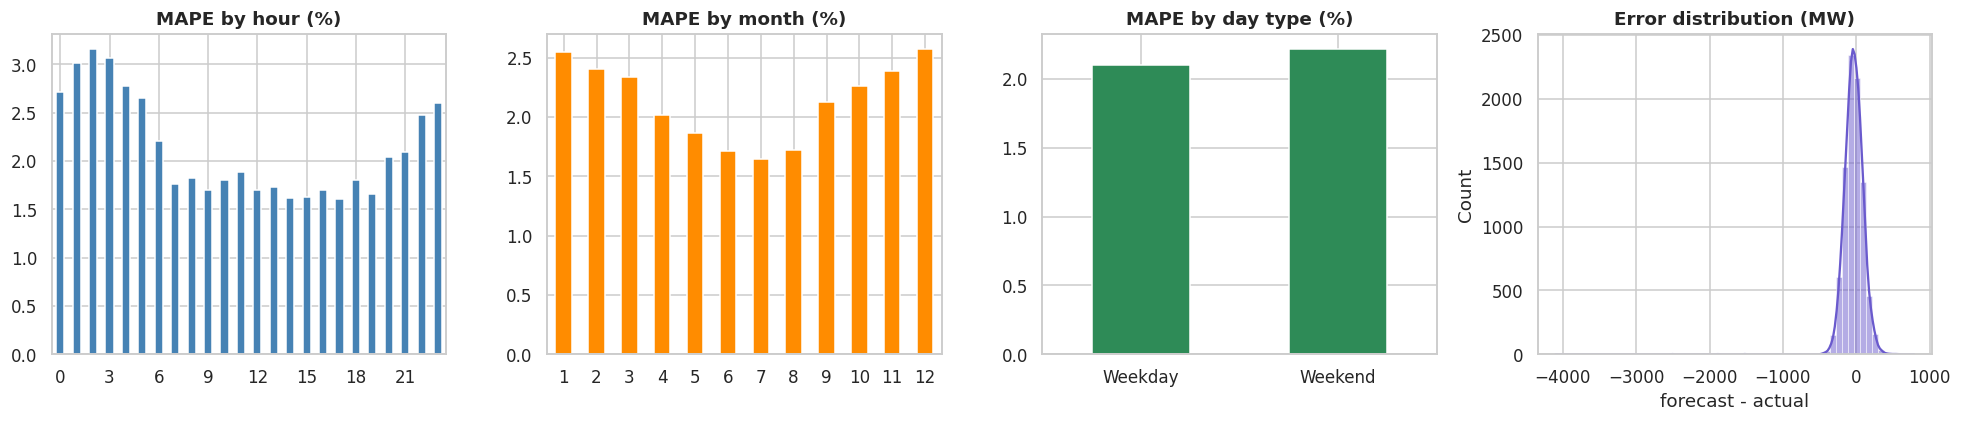

Mean error (bias): -36.1 MW     |     90th percentile |error|: 207 MW
Worst hour of day: 02:00 (MAPE 3.16%), best: 17:00 (1.61%)


In [20]:
res = pd.DataFrame({"actual": y_te, "pred": pred})
res["err"] = res["pred"] - res["actual"]
res["ape"] = (res["err"].abs() / res["actual"]) * 100
res["hour"], res["month"] = res.index.hour, res.index.month
res["daytype"] = np.where(res.index.dayofweek >= 5, "Weekend", "Weekday")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
res.groupby("hour")["ape"].mean().plot.bar(ax=axes[0], color="steelblue", rot=0); axes[0].set(title="MAPE by hour (%)", xlabel="")
axes[0].set_xticks(range(0, 24, 3)); axes[0].set_xticklabels(range(0, 24, 3))
res.groupby("month")["ape"].mean().plot.bar(ax=axes[1], color="darkorange", rot=0); axes[1].set(title="MAPE by month (%)", xlabel="")
res.groupby("daytype")["ape"].mean().plot.bar(ax=axes[2], color="seagreen", rot=0); axes[2].set(title="MAPE by day type (%)", xlabel="")
sns.histplot(res["err"], bins=60, kde=True, ax=axes[3], color="slateblue"); axes[3].set(title="Error distribution (MW)", xlabel="forecast - actual")
plt.tight_layout(); plt.show()

print(f"Mean error (bias): {res['err'].mean():+.1f} MW     |     90th percentile |error|: {res['err'].abs().quantile(.9):.0f} MW")
print(f"Worst hour of day: {res.groupby('hour')['ape'].mean().idxmax():02d}:00 (MAPE {res.groupby('hour')['ape'].mean().max():.2f}%), "
      f"best: {res.groupby('hour')['ape'].mean().idxmin():02d}:00 ({res.groupby('hour')['ape'].mean().min():.2f}%)")

In [21]:
# Is there a holiday effect the model is missing? Check bias on common public-holiday dates.
special = {"Jan 1": (1, 1), "Aug 15": (8, 15), "Oct 2": (10, 2), "Dec 25": (12, 25)}
rows = []
for name, (m_, d_) in special.items():
    s = res[(res.index.month == m_) & (res.index.day == d_)]
    rows.append({"day": name, "mean error (MW)": s["err"].mean(), "MAPE (%)": s["ape"].mean()})
rows.append({"day": "All other days", "mean error (MW)": res["err"].mean(), "MAPE (%)": res["ape"].mean()})
display(pd.DataFrame(rows).set_index("day").round(2))

,mean error (MW),MAPE (%)
day,,
Jan 1,-55.67,2.38
Aug 15,13.42,1.70
Oct 2,-90.41,2.00
Dec 25,-30.06,2.28
All other days,-36.08,2.13


There are only 24 observations for each date, so this holiday check is limited. I did not find a clear difference in error on the dates I checked. I have left holiday features out for now, but I would revisit this if I knew which country's holiday calendar matched the data.

### 9.3 Prediction intervals (CQR)

A point prediction does not show how uncertain it is, so I also make a 90% prediction interval using conformalized quantile regression.

1. Fit 5th- and 95th-percentile LightGBM models on 2020–2022.
2. Use 2023 to calculate how much to widen the interval.
3. Apply that adjustment to the 2024 predictions.

The interval reaches close to 90% coverage on the test year, but that does not mean it will always do so. Coverage can change if demand patterns shift.

Raw quantile band coverage (nominal 90 %)      : 78.7%
Calibrated (CQR) coverage on 2024 (nominal 90 %): 89.3%   |   mean width: 516 MW   |   correction q = 55 MW


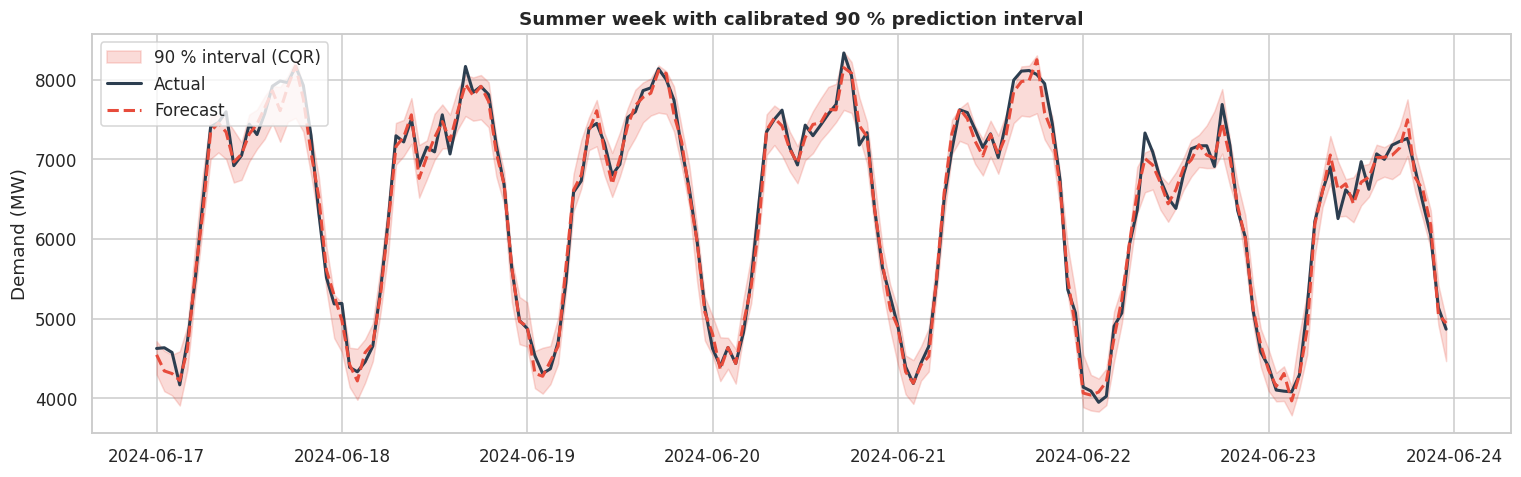

In [22]:
qp = dict(n_estimators=500, learning_rate=0.05, subsample_freq=1, random_state=SEED, n_jobs=-1, verbose=-1, **best_params)
qm = {q: lgb.LGBMRegressor(objective="quantile", alpha=q, **qp).fit(X_tr, y_tr) for q in (0.05, 0.95)}

def raw_band(X_):
    lo_, hi_ = qm[0.05].predict(X_), qm[0.95].predict(X_)
    return np.minimum(lo_, hi_), np.maximum(lo_, hi_)

# Calibrate on the validation year
lo_v, hi_v = raw_band(X_val)
scores = np.maximum(lo_v - y_val.values, y_val.values - hi_v)
alpha = 0.10
q_hat = np.quantile(scores, min(1.0, np.ceil((len(scores) + 1) * (1 - alpha)) / len(scores)))

lo_raw, hi_raw = raw_band(X_te)
lo = pd.Series(lo_raw - q_hat, index=X_te.index); hi = pd.Series(hi_raw + q_hat, index=X_te.index)

cov_raw = float(((y_te.values >= lo_raw) & (y_te.values <= hi_raw)).mean())
coverage = float(((y_te >= lo) & (y_te <= hi)).mean())
width = float((hi - lo).mean())
print(f"Raw quantile band coverage (nominal 90 %)      : {cov_raw:.1%}")
print(f"Calibrated (CQR) coverage on 2024 (nominal 90 %): {coverage:.1%}   |   mean width: {width:.0f} MW   |   correction q = {q_hat:.0f} MW")

a, b = "2024-06-17", "2024-06-23"
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(lo[a:b].index, lo[a:b], hi[a:b], color="#e74c3c", alpha=0.2, label="90 % interval (CQR)")
ax.plot(y_te[a:b], color="#2c3e50", lw=2, label="Actual"); ax.plot(pred[a:b], color="#e74c3c", ls="--", lw=2, label="Forecast")
ax.set(title="Summer week with calibrated 90 % prediction interval", ylabel="Demand (MW)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 9.4 What drives the forecast? (SHAP)

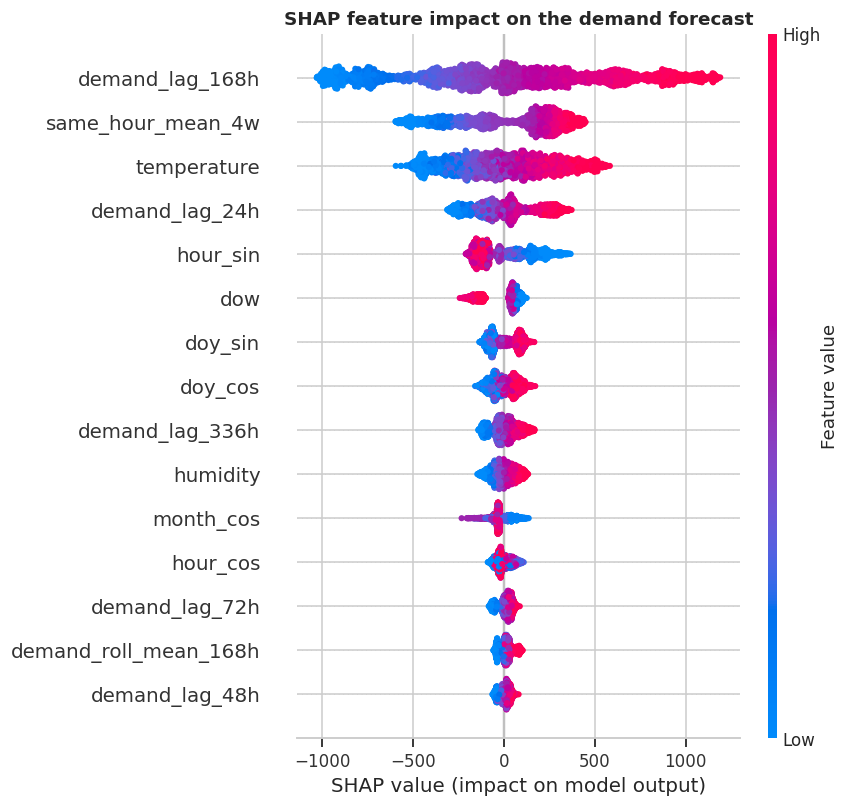

Mean |SHAP| (MW), top 8:


,MW
demand_lag_168h,456.0
same_hour_mean_4w,257.0
temperature,224.0
demand_lag_24h,135.7
hour_sin,127.8
dow,87.4
doy_sin,69.8
doy_cos,57.1


In [23]:
sample = X_te.sample(3000, random_state=SEED)
shap_values = shap.TreeExplainer(final_lgb).shap_values(sample)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, sample, show=False, max_display=15)
plt.title("SHAP feature impact on the demand forecast"); plt.tight_layout(); plt.show()

imp = pd.Series(np.abs(shap_values).mean(0), index=sample.columns).sort_values(ascending=False)
print("Mean |SHAP| (MW), top 8:"); display(imp.head(8).round(1).to_frame("MW"))

SHAP shows that demand from the same hour last week and recent temperature are important to the model. The hour features also help capture the daily shape. Humidity contributes much less.

## 10. Check the first version

My first version reported an RMSE of about 175 MW. When I reviewed the code, I found two issues: the rolling statistics included the current demand value, and the test year was used for early stopping. I test the effect of fixing these one at a time.

In [24]:
def original_features(d, shift_roll):
    f = pd.DataFrame(index=d.index)
    f["hour"], f["dayofweek"], f["month"], f["year"] = d.index.hour, d.index.dayofweek, d.index.month, d.index.year
    f["dayofyear"], f["quarter"] = d.index.dayofyear, d.index.quarter
    f["weekofyear"] = d.index.isocalendar().week.astype(int).values
    f["isWeekend"] = (d.index.dayofweek >= 5).astype(int)
    f["Temperature"], f["Humidity"] = d["Temperature"], d["Humidity"]
    f["demand_lag_24hr"], f["demand_lag_168hr"] = d["Demand"].shift(24), d["Demand"].shift(168)
    base = d["Demand"].shift(24) if shift_roll else d["Demand"]        # This version includes the value being predicted
    f["daily_rolling_mean"], f["demand_rolling_std_24hr"] = base.rolling(24).mean(), base.rolling(24).std()
    return f.dropna()

orig_params = dict(n_estimators=1000, learning_rate=0.01, early_stopping_rounds=50, random_state=SEED, objective="reg:squarederror")
audit = {}

# A. Original setup: rolling-window leak and test-year early stopping
FA = original_features(df, shift_roll=False); ya = df["Demand"].loc[FA.index]
m = xgb.XGBRegressor(**orig_params).fit(FA[FA.index < "2024"], ya[FA.index < "2024"],
                                        eval_set=[(FA[FA.index >= "2024"], ya[FA.index >= "2024"])], verbose=False)
audit["A. Original (leaky rolling + test in eval_set)"] = evaluate(ya[FA.index >= "2024"], m.predict(FA[FA.index >= "2024"]))

# B. Fix the rolling features, but still use the test year for early stopping
FB = original_features(df, shift_roll=True); yb = df["Demand"].loc[FB.index]
m = xgb.XGBRegressor(**orig_params).fit(FB[FB.index < "2024"], yb[FB.index < "2024"],
                                        eval_set=[(FB[FB.index >= "2024"], yb[FB.index >= "2024"])], verbose=False)
audit["B. + rolling windows shifted 24 h"] = evaluate(yb[FB.index >= "2024"], m.predict(FB[FB.index >= "2024"]))

# C. Use validation for early stopping and keep the test year for the final score
tr, va, te = FB.index < "2023", (FB.index >= "2023") & (FB.index < "2024"), FB.index >= "2024"
m = xgb.XGBRegressor(**orig_params).fit(FB[tr], yb[tr], eval_set=[(FB[va], yb[va])], verbose=False)
audit["C. + early stopping on validation"] = evaluate(yb[te], m.predict(FB[te]))

audit["D. Final pipeline (Section 8)"] = evaluate(y_te, test_preds["LightGBM (tuned)"])
audit_table = pd.DataFrame(audit).T.round(2)
display(audit_table)

,RMSE,MAE,MAPE (%),R2
A. Original (leaky rolling + test in eval_set),174.55,123.82,2.59,0.98
B. + rolling windows shifted 24 h,175.88,124.57,2.61,0.98
C. + early stopping on validation,182.18,130.33,2.72,0.98
D. Final pipeline (Section 8),149.92,101.78,2.13,0.99


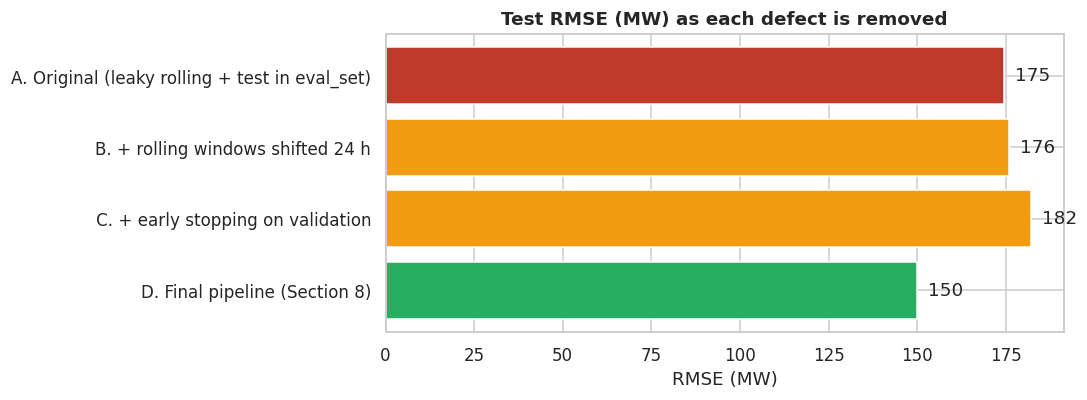

Fixing the rolling-window leak          : RMSE +1.3 MW
Fixing early stopping on the test set    : RMSE +6.3 MW
Honest original -> final pipeline (C->D) : RMSE -32.3 MW  (-18%)


In [25]:
fig, ax = plt.subplots(figsize=(10, 3.8))
vals = audit_table["RMSE"]
ax.barh(vals.index[::-1], vals.values[::-1], color=["#27ae60", "#f39c12", "#f39c12", "#c0392b"])
for y_, v in enumerate(vals.values[::-1]): ax.text(v + 3, y_, f"{v:.0f}", va="center")
ax.set(title="Test RMSE (MW) as each defect is removed", xlabel="RMSE (MW)"); plt.tight_layout(); plt.show()

r = audit_table["RMSE"].values
print(f"Fixing the rolling-window leak          : RMSE {r[1] - r[0]:+.1f} MW")
print(f"Fixing early stopping on the test set    : RMSE {r[2] - r[1]:+.1f} MW")
print(f"Honest original -> final pipeline (C->D) : RMSE {r[3] - r[2]:+.1f} MW  ({(r[3] / r[2] - 1):+.0%})")

### Results of the check

- The rolling feature did include the value being predicted. That is leakage, although its effect was small in this experiment: the target is only one of the 24 values in the rolling mean, and the model also has strong lag features.
- Using 2024 for early stopping also lets the test set influence the model choice, so its score can be a little optimistic.
- Most of the improvement came after adding better features, using a proper validation setup and tuning LightGBM.

This was a useful check because the presence of leakage does not tell me how much it changes the final score. I need to fix the issue and compare the results.

## 11. Save the model

I save the model with the feature list and metadata as well. At prediction time, the input columns need to match the columns used during training.

In [26]:
final_lgb.booster_.save_model(str(ARTIFACTS / "lgbm_day_ahead.txt"))

metadata = {
    "task": "day-ahead hourly electricity demand forecast (MW)",
    "features": list(X_all.columns),
    "n_estimators": int(lgb_best_iter),
    "lightgbm_params": {k: (round(v, 6) if isinstance(v, float) else v) for k, v in best_params.items()},
    "train_window": [str(X_trval.index.min()), str(X_trval.index.max())],
    "test_metrics_2024": evaluate(y_te, test_preds["LightGBM (tuned)"]),
    "interval_90_coverage_2024": coverage,
}
(ARTIFACTS / "model_metadata.json").write_text(json.dumps(metadata, indent=2))

# Reload test: the saved model must reproduce the predictions exactly
reloaded = lgb.Booster(model_file=str(ARTIFACTS / "lgbm_day_ahead.txt"))
assert np.allclose(reloaded.predict(X_te[metadata["features"]]), test_preds["LightGBM (tuned)"].values)
print("Saved model reloads and reproduces predictions:", sorted(p.name for p in ARTIFACTS.iterdir()))

# Metrics for the README / summary
summary = {f"test_{k}_{m.lower().split(' ')[0]}": float(v) for k, row in
           {"naive_168": test_table.loc["Naive-168 (last week)"], "lgbm": test_table.loc["LightGBM (tuned)"]}.items()
           for m, v in row.items()}
summary["audit_original_rmse"] = float(audit_table.iloc[0]["RMSE"]); summary["audit_fixed_rmse"] = float(audit_table.iloc[1]["RMSE"])
summary["coverage"] = coverage
(ARTIFACTS / "metrics.json").write_text(json.dumps(summary, indent=2))

Saved model reloads and reproduces predictions: ['lgbm_day_ahead.txt', 'metrics.json', 'model_metadata.json']


327

## 12. Summary

### Results

- On the 2024 test year, the final model gets **149.9 MW RMSE** and **2.13% MAPE**. The best naive baseline has an RMSE of 321.0 MW.
- The data is split by time, and the test year is not used for model selection.
- The 90% prediction interval covers **89.3%** of the 2024 observations.
- The first version's leakage issues had a relatively small effect here. Most of the improvement came from the features and validation/tuning changes.

### Limitations

- The model uses observed weather. In real use, I would only have weather forecasts, so I need to test with archived forecasts.
- Temperature is capped at 3 °C and 50 °C in the dataset.
- The model under-predicts demand by about 36 MW on average in 2024. The test RMSE is also higher than the validation RMSE, partly because 2024 has the largest peaks.
- The dataset does not identify a country, so I could not properly test local holidays.
- Five years may not include enough rare events, such as major heat waves or outages.

### What I would try next

1. Use archived weather forecasts instead of observed weather.
2. Add a suitable public-holiday calendar and other useful external data.
3. Try a demand-growth adjustment and compare it with a sequence model.
4. Track errors over time and check whether the model needs retraining.
5. Put preprocessing and prediction into a small reusable module or API.